In [ ]:
!pip -q install tensorflow opencv-python-headless pillow matplotlib

In [ ]:
MODEL_PATH = "/content/facemap_3dmm-facial-landmark-detection-w8a8.tflite"

import os
print("exists:", os.path.exists(MODEL_PATH))
print("size:", os.path.getsize(MODEL_PATH) if os.path.exists(MODEL_PATH) else "missing")

exists: True
size: 5531288


In [ ]:
import tensorflow as tf
import numpy as np

interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("INPUT DETAILS")
for x in input_details:
    print(x)

print("\nOUTPUT DETAILS")
for x in output_details:
    print(x)

INPUT DETAILS
{'name': 'image', 'index': 0, 'shape': array([  1, 128, 128,   3], dtype=int32), 'shape_signature': array([  1, 128, 128,   3], dtype=int32), 'dtype': <class 'numpy.uint8'>, 'quantization': (0.0039185648784041405, 0), 'quantization_parameters': {'scales': array([0.00391856], dtype=float32), 'zero_points': array([0], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}

OUTPUT DETAILS
{'name': 'parameters_3dmm', 'index': 89, 'shape': array([  1, 265], dtype=int32), 'shape_signature': array([  1, 265], dtype=int32), 'dtype': <class 'numpy.uint8'>, 'quantization': (0.056204311549663544, 132), 'quantization_parameters': {'scales': array([0.05620431], dtype=float32), 'zero_points': array([132], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


(1000, 1000)


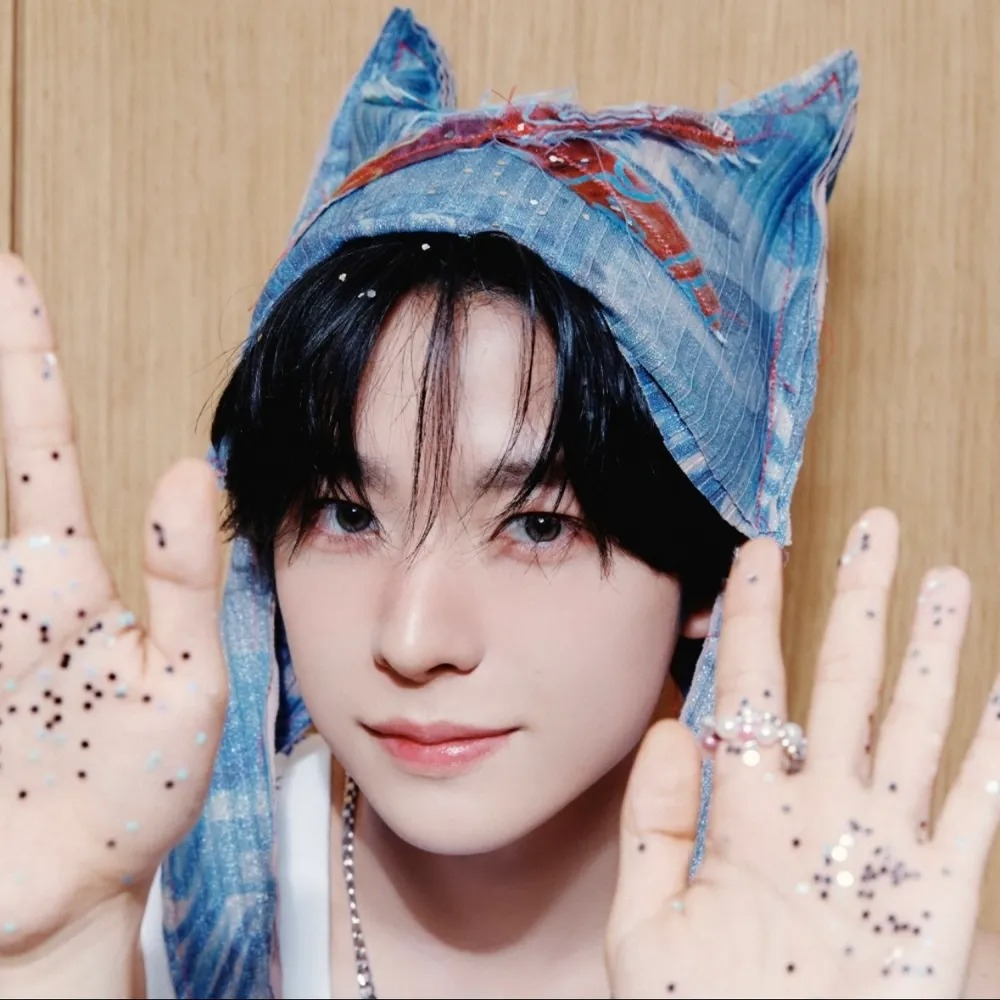

In [ ]:
IMAGE_PATH = "/content/test_face.jpeg"

from PIL import Image
img = Image.open(IMAGE_PATH).convert("RGB")
print(img.size)
img

In [ ]:
from PIL import Image
import numpy as np

img = Image.open(IMAGE_PATH).convert("RGB")
img_resized = img.resize((128, 128))

x = np.array(img_resized)

in_dtype = input_details[0]["dtype"]
print("input dtype =", in_dtype)

if in_dtype == np.uint8:
    x_in = x.astype(np.uint8)
elif in_dtype == np.int8:
    # quantization 파라미터 사용
    scale, zero_point = input_details[0]["quantization"]
    if scale == 0:
        raise ValueError("input quantization scale is 0")
    x_in = np.round(x / scale + zero_point).astype(np.int8)
else:
    # 혹시 float 모델이면 0~1 정규화
    x_in = (x / 255.0).astype(np.float32)

x_in = np.expand_dims(x_in, axis=0)
print("x_in shape:", x_in.shape, x_in.dtype)

input dtype = <class 'numpy.uint8'>
x_in shape: (1, 128, 128, 3) uint8


In [ ]:
interpreter.set_tensor(input_details[0]["index"], x_in)
interpreter.invoke()

outputs = []
for od in output_details:
    out = interpreter.get_tensor(od["index"])
    outputs.append(out)
    print("output shape:", out.shape, "dtype:", out.dtype)

output shape: (1, 265) dtype: uint8


In [ ]:
raw = outputs[0].reshape(-1)
print("raw len =", len(raw))
print(raw[:30])

raw len = 265
[119 123 133 135 132 132 136 131 132 131 128 130 131 132 130 132 128 133
 130 130 135 132 132 128 133 131 133 130 132 129]


In [ ]:
od = output_details[0]
raw_q = outputs[0].reshape(-1)

if np.issubdtype(raw_q.dtype, np.integer):
    scale, zero_point = od["quantization"]
    print("output quantization:", scale, zero_point)
    raw_f = (raw_q.astype(np.float32) - zero_point) * scale
else:
    raw_f = raw_q.astype(np.float32)

print("float len =", len(raw_f))
print(raw_f[:30])

output quantization: 0.056204311549663544 132
float len = 265
[-0.730656   -0.5058388   0.05620431  0.16861293  0.          0.
  0.22481725 -0.05620431  0.         -0.05620431 -0.22481725 -0.11240862
 -0.05620431  0.         -0.11240862  0.         -0.22481725  0.05620431
 -0.11240862 -0.11240862  0.16861293  0.          0.         -0.22481725
  0.05620431 -0.05620431  0.05620431 -0.11240862  0.         -0.16861293]


In [ ]:
np.savetxt("/content/meta.txt", raw_f, fmt="%.10f")
print("saved: /content/meta.txt")

saved: /content/meta.txt


In [ ]:
# NOTE: 3.10 <= PYTHON_VERSION < 3.14 is supported.
!pip install "qai-hub-models[facemap-3dmm]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.9/103.9 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.6/503.6 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.7/117.7 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.2/139.2 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
import qai_hub_models

root = os.path.dirname(qai_hub_models.__file__)
print("qai_hub_models root =", root)

# facemap 관련 파일/폴더 찾기
!find {root} | grep "facemap_3dmm" | head -100

print("\n=== asset candidates ===")
!find {root} \( -iname "meanFace.npy" -o -iname "shapeBasis.npy" -o -iname "blendShape.npy" \)

qai_hub_models root = /usr/local/lib/python3.12/dist-packages/qai_hub_models
/usr/local/lib/python3.12/dist-packages/qai_hub_models/evaluators/__pycache__/facemap_3dmm_evaluator.cpython-312.pyc
/usr/local/lib/python3.12/dist-packages/qai_hub_models/evaluators/facemap_3dmm_evaluator.py
/usr/local/lib/python3.12/dist-packages/qai_hub_models/models/facemap_3dmm
/usr/local/lib/python3.12/dist-packages/qai_hub_models/models/facemap_3dmm/README.md
/usr/local/lib/python3.12/dist-packages/qai_hub_models/models/facemap_3dmm/info.yaml
/usr/local/lib/python3.12/dist-packages/qai_hub_models/models/facemap_3dmm/model.py
/usr/local/lib/python3.12/dist-packages/qai_hub_models/models/facemap_3dmm/resnet_score_rgb.py
/usr/local/lib/python3.12/dist-packages/qai_hub_models/models/facemap_3dmm/__pycache__
/usr/local/lib/python3.12/dist-packages/qai_hub_models/models/facemap_3dmm/__pycache__/conftest.cpython-312.pyc
/usr/local/lib/python3.12/dist-packages/qai_hub_models/models/facemap_3dmm/__pycache__/test

In [ ]:
!python -m qai_hub_models.models.facemap_3dmm.demo --help

usage: demo.py [-h] [--eval-mode {fp,on-device}] [--hub-model-id HUB_MODEL_ID]
               [--device DEVICE_STR | --chipset CHIPSET]
               [--device-os DEVICE_OS] [--output-dir OUTPUT_DIR]
               [--inference-options INFERENCE_OPTIONS]
               [--target-runtime {tflite, qnn_dlc, qnn_context_binary, onnx, precompiled_qnn_onnx, genie, onnxruntime_genai, voice_ai, llama_cpp_cpu, llama_cpp_gpu, llama_cpp_npu}]
               [--precision {w8a16, float, w8a8} | --quantize [{w8a16,w8a8}]]
               [--image IMAGE] [--face-box FACE_BOX]

options:
  -h, --help            show this help message and exit
  --eval-mode {fp,on-device}
                        Run the model in one of the following modes:
                          - fp: run floating point model
                          - on-device: physical device via AI Hub Workbench (slow) (default: fp)
  --hub-model-id HUB_MODEL_ID
                        If mode==on-device, uses this model Hub model ID. Provide co

In [ ]:
!python -m qai_hub_models.models.facemap_3dmm.demo --quantize w8a8

Model Loaded
Displaying image
Error: no "view" mailcap rules found for type "image/png"
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening '/tmp/tmpqmnoc9l8.PNG'


In [ ]:
import os
import qai_hub_models

root = os.path.dirname(qai_hub_models.__file__)
print("package root:", root)

!find {root} \( -iname "meanFace.npy" -o -iname "shapeBasis.npy" -o -iname "blendShape.npy" \)

print("\n=== wider search in home/cache ===")
!find /root /content 2>/dev/null | grep -E "meanFace.npy|shapeBasis.npy|blendShape.npy|facemap_3dmm"

package root: /usr/local/lib/python3.12/dist-packages/qai_hub_models

=== wider search in home/cache ===
/root/.qaihm/qai-hub-models/models/facemap_3dmm
/root/.qaihm/qai-hub-models/models/facemap_3dmm/v1
/root/.qaihm/qai-hub-models/models/facemap_3dmm/v1/face_img.jpg
/root/.qaihm/qai-hub-models/models/facemap_3dmm/v1/shapeBasis.npy
/root/.qaihm/qai-hub-models/models/facemap_3dmm/v1/meanFace.npy
/root/.qaihm/qai-hub-models/models/facemap_3dmm/v1/resnet_wd2_weak_score_1202_3ch.pth.tar
/root/.qaihm/qai-hub-models/models/facemap_3dmm/v1/blendShape.npy


In [ ]:
import os

ASSET_DIR = "/root/.qaihm/qai-hub-models/models/facemap_3dmm/v1"

MEAN_FACE_PATH   = os.path.join(ASSET_DIR, "meanFace.npy")
SHAPE_BASIS_PATH = os.path.join(ASSET_DIR, "shapeBasis.npy")
BLEND_PATH       = os.path.join(ASSET_DIR, "blendShape.npy")

for p in [MEAN_FACE_PATH, SHAPE_BASIS_PATH, BLEND_PATH]:
    print(p, os.path.exists(p))

/root/.qaihm/qai-hub-models/models/facemap_3dmm/v1/meanFace.npy True
/root/.qaihm/qai-hub-models/models/facemap_3dmm/v1/shapeBasis.npy True
/root/.qaihm/qai-hub-models/models/facemap_3dmm/v1/blendShape.npy True


In [ ]:
import numpy as np
import os

ASSET_DIR = "/root/.qaihm/qai-hub-models/models/facemap_3dmm/v1"

MEAN_FACE_PATH   = os.path.join(ASSET_DIR, "meanFace.npy")
SHAPE_BASIS_PATH = os.path.join(ASSET_DIR, "shapeBasis.npy")
BLEND_PATH       = os.path.join(ASSET_DIR, "blendShape.npy")

mean_face   = np.load(MEAN_FACE_PATH)
shape_basis = np.load(SHAPE_BASIS_PATH)
blend_shape = np.load(BLEND_PATH)

print("mean_face:", mean_face.shape)
print("shape_basis:", shape_basis.shape)
print("blend_shape:", blend_shape.shape)

mean_face: (204,)
shape_basis: (44676,)
blend_shape: (7956,)


In [ ]:
import numpy as np
import os

META_PATH = "/content/meta.txt"   # 네 meta.txt 경로
ASSET_DIR = "/root/.qaihm/qai-hub-models/models/facemap_3dmm/v1"

MEAN_FACE_PATH   = os.path.join(ASSET_DIR, "meanFace.npy")
SHAPE_BASIS_PATH = os.path.join(ASSET_DIR, "shapeBasis.npy")
BLEND_PATH       = os.path.join(ASSET_DIR, "blendShape.npy")

coeff = np.loadtxt(META_PATH).astype(np.float32).reshape(-1)
print("coeff len:", len(coeff))
assert len(coeff) == 265

alpha_id  = coeff[0:219]
alpha_exp = coeff[219:258]
pitch     = float(coeff[258])
yaw       = float(coeff[259])
roll      = float(coeff[260])
tx        = float(coeff[261])
ty        = float(coeff[262])
f         = float(coeff[263])
extra     = float(coeff[264])

print("alpha_id:", alpha_id.shape)
print("alpha_exp:", alpha_exp.shape)
print("pose:", pitch, yaw, roll)
print("tx ty f:", tx, ty, f)

coeff len: 265
alpha_id: (219,)
alpha_exp: (39,)
pose: -0.11240862309932709 -0.22481724619865417 0.056204311549663544
tx ty f: 0.11240862309932709 0.22481724619865417 -1.5737206935882568


In [ ]:
mean_face   = np.load(MEAN_FACE_PATH).astype(np.float32).reshape(68, 3)
shape_basis = np.load(SHAPE_BASIS_PATH).astype(np.float32).reshape(204, 219)
blend_shape = np.load(BLEND_PATH).astype(np.float32).reshape(204, 39)

print("mean_face:", mean_face.shape)      # (68, 3)
print("shape_basis:", shape_basis.shape)  # (204, 219)
print("blend_shape:", blend_shape.shape)  # (204, 39)

mean_face: (68, 3)
shape_basis: (204, 219)
blend_shape: (204, 39)


In [ ]:
def reconstruct_landmark3d(alpha_id, alpha_exp, mean_face, shape_basis, blend_shape):
    base = mean_face.reshape(-1, 1).astype(np.float32)  # (204,1)

    id_part  = shape_basis @ alpha_id.reshape(-1, 1).astype(np.float32)   # (204,1)
    exp_part = blend_shape @ alpha_exp.reshape(-1, 1).astype(np.float32)  # (204,1)

    face_vec = (base + id_part + exp_part).reshape(-1)   # (204,)
    return face_vec.reshape(68, 3).astype(np.float32)

landmark3d = reconstruct_landmark3d(alpha_id, alpha_exp, mean_face, shape_basis, blend_shape)
print("landmark3d:", landmark3d.shape)
print(landmark3d[:5])

landmark3d: (68, 3)
[[-69.38931   20.667982  23.664038]
 [-68.721855  -4.642289  19.349167]
 [-64.85122  -26.425196  16.241331]
 [-58.3077   -46.153217  20.755386]
 [-42.126755 -56.39409   31.122377]]


In [ ]:
import numpy as np

def facemap_denorm_pose_and_camera(pitch, yaw, roll, tx, ty, f):
    pitch = pitch * np.pi / 2
    yaw   = yaw   * np.pi / 2
    roll  = roll  * np.pi / 2
    tx    = tx * 60
    ty    = ty * 60
    tz    = 500.0
    f     = f * 150 + 450
    return pitch, yaw, roll, tx, ty, tz, f

def apply_pose_and_project(pts3d, pitch, yaw, roll, tx, ty, f):
    pitch, yaw, roll, tx, ty, tz, f = facemap_denorm_pose_and_camera(
        pitch, yaw, roll, tx, ty, f
    )

    p_matrix = np.array([
        [1, 0, 0],
        [0, np.cos(-np.pi), -np.sin(-np.pi)],
        [0, np.sin(-np.pi),  np.cos(-np.pi)],
    ], dtype=np.float32)

    roll_matrix = np.array([
        [np.cos(-roll), -np.sin(-roll), 0],
        [np.sin(-roll),  np.cos(-roll), 0],
        [0, 0, 1],
    ], dtype=np.float32)

    yaw_matrix = np.array([
        [ np.cos(-yaw), 0, np.sin(-yaw)],
        [ 0,            1, 0           ],
        [-np.sin(-yaw), 0, np.cos(-yaw)],
    ], dtype=np.float32)

    pitch_matrix = np.array([
        [1, 0, 0],
        [0, np.cos(-pitch), -np.sin(-pitch)],
        [0, np.sin(-pitch),  np.cos(-pitch)],
    ], dtype=np.float32)

    r_matrix = yaw_matrix @ (pitch_matrix @ (p_matrix @ roll_matrix))

    vertices = pts3d @ r_matrix.T
    vertices[:, 0] += tx
    vertices[:, 1] += ty
    vertices[:, 2] += tz

    pts2d = vertices[:, 0:2] * f / tz
    return pts2d.astype(np.float32)

landmark68 = apply_pose_and_project(landmark3d, pitch, yaw, roll, tx, ty, f)
print("landmark68:", landmark68.shape)
print(landmark68[:5])

landmark68: (68, 2)
[[-28.27399    -3.6989014]
 [-27.617538    6.62153  ]
 [-25.815054   15.671601 ]
 [-24.02835    24.531593 ]
 [-19.127886   30.208714 ]]


In [ ]:
def eye6_to_eye8(eye6):
    p0, p1, p2, p3, p4, p5 = eye6

    up_a = p0 * 0.33 + p1 * 0.67
    up_b = (p1 + p2) / 2.0
    up_c = p3 * 0.33 + p2 * 0.67

    low_a = p3 * 0.33 + p4 * 0.67
    low_b = (p4 + p5) / 2.0
    low_c = p0 * 0.33 + p5 * 0.67

    return np.stack([p0, up_a, up_b, up_c, p3, low_a, low_b, low_c], axis=0)

def landmark68_to_72(lm68):
    jaw   = lm68[0:17]
    lbrow = lm68[17:22]
    rbrow = lm68[22:27]
    nose  = lm68[27:36]
    leye6 = lm68[36:42]
    reye6 = lm68[42:48]
    mouth = lm68[48:68]

    leye8 = eye6_to_eye8(leye6)
    reye8 = eye6_to_eye8(reye6)

    lm72 = np.concatenate([jaw, lbrow, rbrow, nose, leye8, reye8, mouth], axis=0)
    return lm72.astype(np.float32)

landmark72 = landmark68_to_72(landmark68)
print("landmark72:", landmark72.shape)

landmark72: (72, 2)


In [ ]:
REF_LANDMARK_PATH = "/content/landmark.txt"
REF_HEADPOSE_PATH = "/content/headpose.txt"

In [ ]:
REF_LANDMARK_PATH = "/content/landmark.txt"
REF_HEADPOSE_PATH = "/content/headpose.txt"

ref_landmark = np.loadtxt(REF_LANDMARK_PATH).astype(np.float32)
ref_headpose = np.loadtxt(REF_HEADPOSE_PATH).astype(np.float32)

print("ref_landmark:", ref_landmark.shape)
print("ref_headpose:", ref_headpose.shape)

# 여기 추가: 현재 예측 landmark 검사
print("landmark72 type:", type(landmark72))
print("landmark72 shape:", getattr(landmark72, "shape", None))

landmark72 = np.asarray(landmark72, dtype=np.float32)

assert ref_landmark.shape == (72, 2), f"ref_landmark shape mismatch: {ref_landmark.shape}"
assert ref_headpose.shape == (6,), f"ref_headpose shape mismatch: {ref_headpose.shape}"
assert landmark72.shape == (72, 2), f"landmark72 shape mismatch: {landmark72.shape}"
assert np.isfinite(landmark72).all(), "landmark72 has nan or inf"
assert np.isfinite(ref_landmark).all(), "ref_landmark has nan or inf"

def align_landmark_to_ref(pred, ref):
    pred = np.asarray(pred, dtype=np.float32).copy()
    ref  = np.asarray(ref, dtype=np.float32).copy()

    cands = []
    for sx in [1.0, -1.0]:
        for sy in [1.0, -1.0]:
            p = pred.copy()
            p[:, 0] *= sx
            p[:, 1] *= sy

            p_center = p.mean(axis=0, keepdims=True)
            r_center = ref.mean(axis=0, keepdims=True)

            p0 = p - p_center
            r0 = ref - r_center

            p_scale = np.max(np.linalg.norm(p0, axis=1))
            r_scale = np.max(np.linalg.norm(r0, axis=1))

            if p_scale < 1e-8:
                raise ValueError("pred landmark scale is too small")
            if r_scale < 1e-8:
                raise ValueError("ref landmark scale is too small")

            p1 = p0 / p_scale * r_scale + r_center
            err = np.mean(np.linalg.norm(p1 - ref, axis=1))
            cands.append((err, p1))

    cands.sort(key=lambda x: x[0])
    return cands[0][1]

landmark72_aligned = align_landmark_to_ref(landmark72, ref_landmark)
print("aligned shape:", landmark72_aligned.shape)
print(landmark72_aligned[:5])

ref_landmark: (72, 2)
ref_headpose: (6,)
landmark72 type: <class 'numpy.ndarray'>
landmark72 shape: (72, 2)
aligned shape: (72, 2)
[[-0.18958752 -0.2039914 ]
 [-0.18193926 -0.08374916]
 [-0.16093871  0.02169221]
 [-0.14012203  0.124919  ]
 [-0.08302724  0.19106251]]


In [ ]:
print("landmark68:", landmark68.shape)
print("landmark72:", landmark72.shape)
print("ref_landmark:", ref_landmark.shape)

landmark68: (68, 2)
landmark72: (72, 2)
ref_landmark: (72, 2)


In [ ]:
headpose6 = np.array([
    pitch,
    yaw,
    roll,
    tx,
    ty,
    f
], dtype=np.float32)

print(headpose6)

[-0.11240862 -0.22481725  0.05620431  0.11240862  0.22481725 -1.5737207 ]


In [ ]:
OUT_DIR = "/content/f2f_converted"
os.makedirs(OUT_DIR, exist_ok=True)

np.savetxt(os.path.join(OUT_DIR, "landmark.txt"), landmark72_aligned, fmt="%.10f")
np.savetxt(os.path.join(OUT_DIR, "headpose.txt"), headpose6, fmt="%.10f")

print("saved:")
print(os.path.join(OUT_DIR, "landmark.txt"))
print(os.path.join(OUT_DIR, "headpose.txt"))

saved:
/content/f2f_converted/landmark.txt
/content/f2f_converted/headpose.txt


In [ ]:
lm = np.loadtxt("/content/f2f_converted/landmark.txt")
hp = np.loadtxt("/content/f2f_converted/headpose.txt")

print("landmark shape:", lm.shape)  # (72, 2)
print("headpose shape:", hp.shape)  # (6,)
print(lm[:5])
print(hp)

landmark shape: (72, 2)
headpose shape: (6,)
[[-0.18958752 -0.2039914 ]
 [-0.18193926 -0.08374916]
 [-0.16093871  0.02169221]
 [-0.14012203  0.124919  ]
 [-0.08302724  0.19106251]]
[-1.76571056e-01 -3.53142112e-01  8.82855281e-02  6.74451733e+00
  1.34890347e+01  2.13941895e+02]
